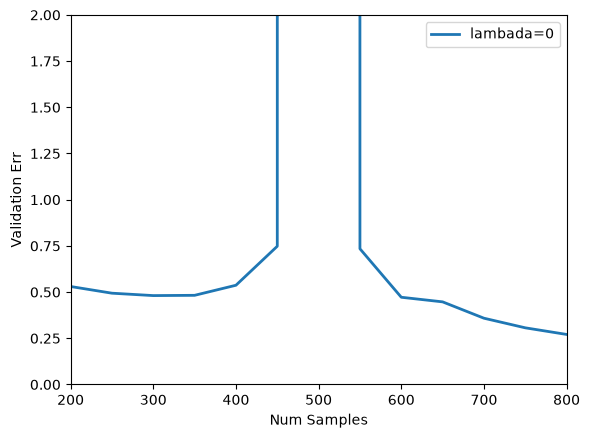

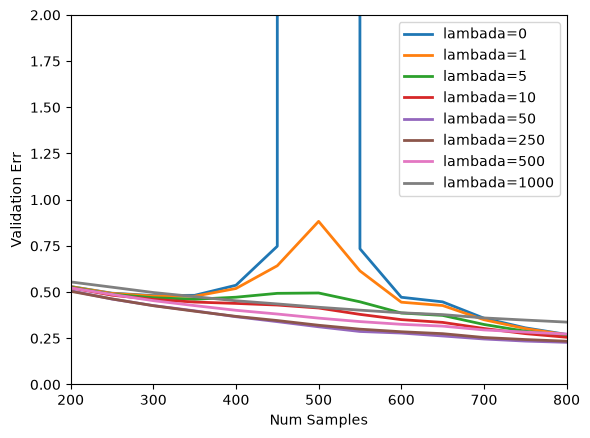

In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def read_csv(train_or_val,size=''):
    path=train_or_val+size
    # x 列是被引号包住、跨多行的向量字符串 "[ a b c ... ]"，np.loadtxt 无法解析
    # csv 模块能正确处理带引号的多行字段，再把方括号里的内容按空白切分成浮点数
    inputs=[]
    labels=[]
    with open(path) as file:
        reader=csv.reader(file)
        headers=next(reader)
        for x_str,y_str in reader:
            inputs.append(np.array(x_str.strip('[]').split(),dtype=float))
            labels.append(float(y_str))

    return np.array(inputs),np.array(labels)

def train(X,Y,lamda):
    beta_lamda=np.linalg.pinv(X.T @ X + lamda * np.eye(X.shape[1])) @ X.T @ Y
    return beta_lamda

def calculate_mse(X_v,beta,Y):
    return 0.5*np.mean((X_v @ beta - Y)**2)

def draw(samples,val_err,lamda):
    plt.plot(samples,val_err,linewidth=2,label='lambada='+str(lamda))
    plt.xlabel('Num Samples')
    plt.ylabel('Validation Err')
    plt.legend()
    plt.xlim(200,800)
    plt.ylim(0,2)


def main():
    samples=[]
    val_err=[]
    val_inputs,val_labels=read_csv('validation.csv')
    fig=plt.figure()
    for i in range(200,801,50):
        train_inputs,train_labels=read_csv('train'+str(i)+'.csv')
        beta=train(train_inputs,train_labels,0)
        mse=calculate_mse(val_inputs,beta,val_labels)
        samples.append(i)
        val_err.append(mse)
    draw(samples,val_err,0)
    plt.savefig('lambda=0.png',dpi=300)
    plt.show()

    lambdas=[0,1,5,10,50,250,500,1000]
    fig=plt.figure()
    for lamda in lambdas:
        samples=[]
        val_err=[]
        for i in range(200,801,50):
            train_inputs,train_labels=read_csv('train'+str(i)+'.csv')
            beta=train(train_inputs,train_labels,lamda)
            mse=calculate_mse(val_inputs,beta,val_labels)
            samples.append(i)
            val_err.append(mse)
        draw(samples,val_err,lamda)
    plt.savefig('lambdas.png',dpi=300)
    plt.show()
    
if __name__=='__main__':
    main()       